In [4]:
import torch
import torch.nn.functional as F

import matplotlib
import matplotlib.pyplot as plt
import utilities_tools_and_graph as graph_tools

from DIC_Net import Network, funcs, speckle_dataset, Hermite
from DIC_Net import dic_tools as dic
dic.load_interp_kernels()

graph_tools.set_theme(False)

path_print = 'rapport/Figures/'

Pytorch device: cuda
NVIDIA GeForce RTX 3070 Laptop GPU


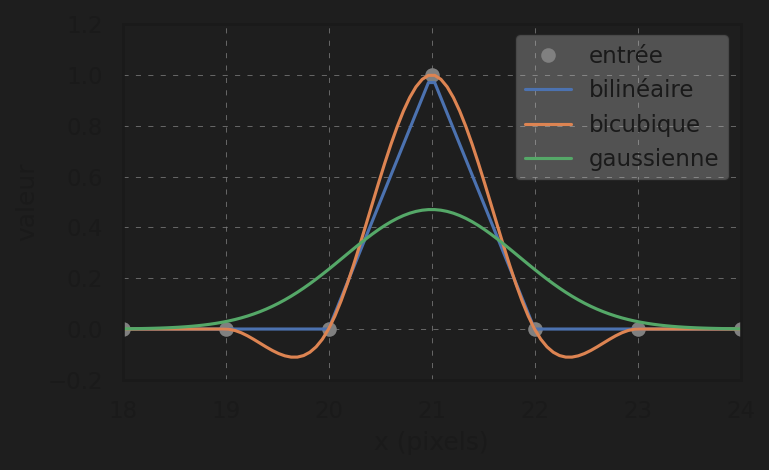

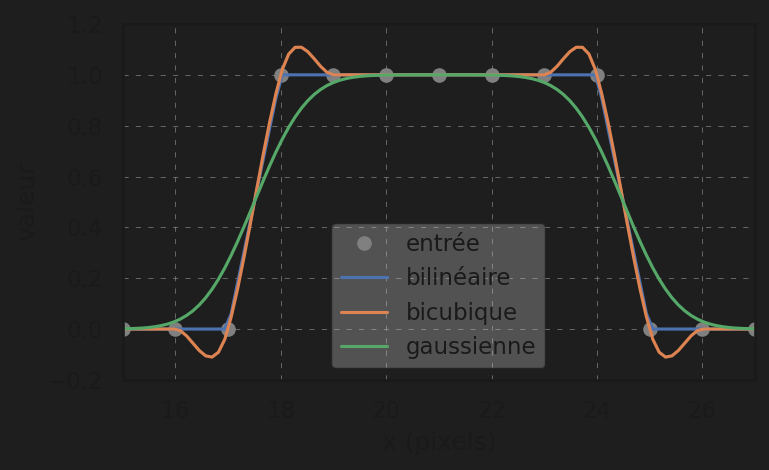

In [2]:
def plot_interp_IRs_0(x, u_interp, y_lin, y_cub, y_gauss):
    fig, ax = plt.subplots(figsize=(5,3))
    # ax2 = ax.twinx()
    # ax2.grid(visible=False)
    ax.plot(x, 'o', color='0.5', label='entrée')
    # ax2.set_ylabel('entrée')
    ax.plot(u_interp, y_lin, label='bilinéaire')
    ax.plot(u_interp, y_cub, label='bicubique')
    ax.plot(u_interp, y_gauss, label='gaussienne')
    ax.set_xlim(u_interp[[0, -1]])
    ax.legend()
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('valeur')

    ylim = [-0.2, 1.2]
    ax.set_ylim(ylim)
    # ax2.set_ylim(ylim)
    fig.tight_layout(pad=0.2)
    return fig

def plot_interp_IRs():
    ic = 21
    x = torch.zeros((2*ic+1,)*2, dtype=torch.float)
    x[ic, ic] = 1.
    x[:, ic] = 1.

    u_interp = torch.linspace(ic-3, ic+3, 100)
    v_interp = torch.tensor([ic], dtype=torch.float)
    xi, yi = torch.meshgrid(u_interp, v_interp, indexing='xy')
    xyi = torch.cat((xi, yi)).T

    xyi_normed = (xyi / torch.tensor([x.shape[-1]-1, x.shape[-2]-1]) * 2) - 1

    y_lin = F.grid_sample(
        x[None, None],
        xyi_normed[None, None],
        mode='bilinear',
        align_corners=True
    ).ravel()

    y_cub = F.grid_sample(
        x[None, None],
        xyi_normed[None, None],
        mode='bicubic',
        align_corners=True
    ).ravel()

    y_gauss = dic.interp_img(x, xi.ravel(), yi.ravel())

    fig = plot_interp_IRs_0(x[ic], u_interp, y_lin, y_cub, y_gauss)
    graph_tools.savefig(fig, path_print + 'interp-1')

    n = 3
    # plateau
    u_interp = torch.linspace(ic-n-3, ic+n+3, 100)
    v_interp = torch.tensor([ic], dtype=torch.float)
    xi, yi = torch.meshgrid(u_interp, v_interp, indexing='xy')
    xyi = torch.cat((xi, yi)).T

    xyi_normed = (xyi / torch.tensor([x.shape[-1]-1, x.shape[-2]-1]) * 2) - 1

    x[:, ic-n:ic+n+1] = 1.

    y_lin = F.grid_sample(
        x[None, None],
        xyi_normed[None, None],
        mode='bilinear',
        align_corners=True
    ).ravel()

    y_cub = F.grid_sample(
        x[None, None],
        xyi_normed[None, None],
        mode='bicubic',
        align_corners=True
    ).ravel()

    y_gauss = dic.interp_img(x, xi.ravel(), yi.ravel())

    fig = plot_interp_IRs_0(x[ic], u_interp, y_lin, y_cub, y_gauss)
    graph_tools.savefig(fig, path_print + 'interp-2')


plot_interp_IRs()

In [11]:
dataset = speckle_dataset.SpeckleDataset(N0=1, scale=4, mode='full')
dataset.init_dataset0()

DATALOADER : FULL DATA


In [41]:
from torchvision import transforms

rmin = 0.6
rmax=3.4
graymax = 0.9
scale = 4
shape = 128, 128
image = torch.zeros((shape[0]*scale, shape[1]*scale), dtype=torch.float)
factor = shape[0] * shape[1] / 512**2
for i in range(4):
    dic.generate_speckles(image, int(factor*16000/4), rmin*scale, rmax*scale, graymax)
    I = torch.stack((image,)*3, dim=2)
    I = (I.numpy()*255).astype('uint8')
    matplotlib.image.imsave(f'diaporama/Figures/images/I-{i}.png', I)


rmin = 6.5 * scale
rmax = 10.5 * scale
dic.generate_speckles(image, 4, rmin, rmax, graymax)
I = torch.stack((image,)*3, dim=2)
I = (I.numpy()*255).astype('uint8')
matplotlib.image.imsave(f'diaporama/Figures/images/I-{i+1}.png', I)

image = F.avg_pool2d(
    image.reshape((1,) + image.shape), kernel_size=scale,
    stride=scale, padding=0
)
image = transforms.functional.gaussian_blur(image, 5)[0]

import matplotlib
I = torch.stack((image,)*3, dim=2)
I = (I.numpy()*255).astype('uint8')
matplotlib.image.imsave(f'diaporama/Figures/images/I-{i+2}.png', I)

image += torch.rand(image.shape) * (5/256)
I = torch.stack((image,)*3, dim=2)
I = (I.numpy()*255).astype('uint8')
matplotlib.image.imsave(f'diaporama/Figures/images/I-{i+3}.png', I)

## image transformations

In [2]:
dataset = speckle_dataset.SpeckleDataset(
    N0=1, scale=4, mode='displacement'
)
dataset.init_dataset0()
image = dataset.images[0].clone()

DATALOADER : DISPLACEMENT


In [6]:
def save_image(image, filename):
    I = torch.stack((image,)*3, dim=2)
    I = (I.numpy()*255).astype('uint8')
    matplotlib.image.imsave(f'diaporama/Figures/images/{filename}.png', I)

image_inv = 1. - image
image_mirror = image.flip(1)
image_mirror_inv = 1. - image_mirror
for i in range(4):
    save_image(image.rot90(i), f'speckle_rot{i}')
    save_image(image_mirror.rot90(i), f'speckle_mirror_rot{i}')
    save_image(image_inv.rot90(i), f'speckle_inv_rot{i}')
    save_image(image_mirror_inv.rot90(i), f'speckle_mirror_inv_rot{i}')


## image pair

In [79]:
dataset = speckle_dataset.SpeckleDataset(
    N0=1, scale=4, mode='displacement'
)
dataset.init_dataset0()

torch.manual_seed(6)
(img_ref, img_def), y, _ = dataset.__getitem__(0, case=1)


DATALOADER : DISPLACEMENT


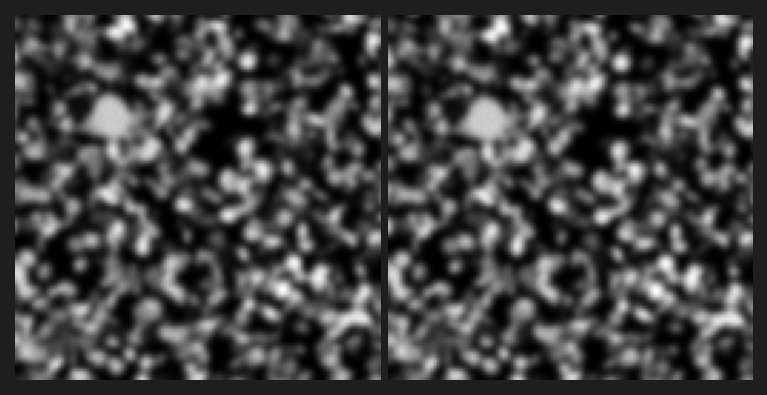

In [89]:
fig, axs = plt.subplots(ncols=2, figsize=(5., 2.5))
axs[0].imshow(img_ref, cmap='gray')
axs[1].imshow(img_def, cmap='gray')
axs[0].axis('off'), axs[0].grid(visible=False)
axs[1].axis('off'), axs[1].grid(visible=False)
# axs[0].set_title('image de référence')
# axs[1].set_title('image déformée')
fig.tight_layout(pad=0.2)
graph_tools.savefig(fig, 'diaporama/Figures/' + 'image_pair')

/tmp/ipykernel_10912/4134882127.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.2, rect=[0, -0.1, 1, 1.23])


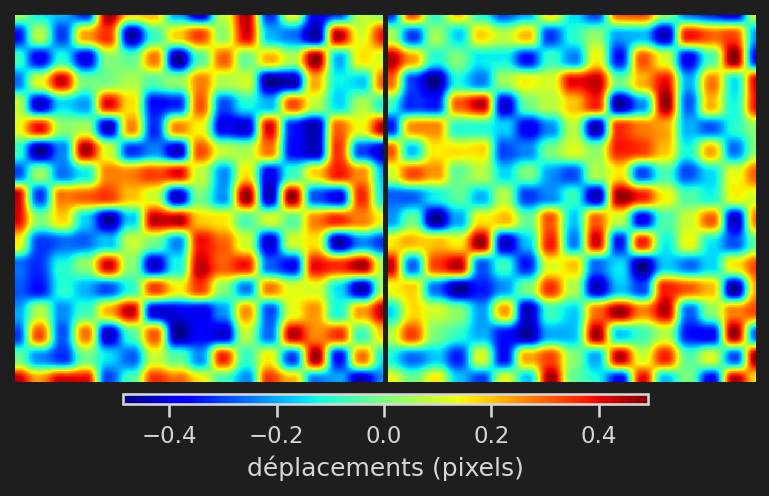

In [91]:
fig, axs = plt.subplots(ncols=2, figsize=(5, 3.35))
im = axs[0].imshow(y[0], cmap='jet')

for i in range(2):
    im = axs[i].imshow(y[i], cmap='jet')
    axs[i].axis('off')
    axs[i].grid(visible=False)
    # axs[i].set_title(r'$\Delta$ ' + 'uv'[i])

cax = fig.add_axes([0.15, 0.155, 0.7, 0.02])  # [left, bottom, width, height]

# Add the colorbar using the 'im' object and the 'cax' axis
cb = fig.colorbar(im, cax=cax, orientation='horizontal')
cb.set_label('déplacements (pixels)')

fig.tight_layout(pad=0.2, rect=[0, -0.1, 1, 1.23])
graph_tools.savefig(fig, 'diaporama/Figures/' + 'image_pair_deplacements')

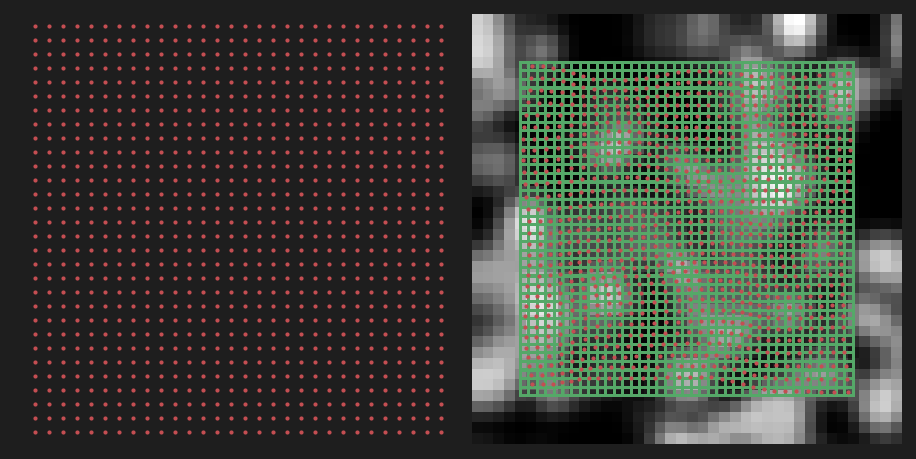

In [78]:
image = dataset.images[0].clone()

margin = 5
image = image[:40, :40]
img_ref = img_ref[:30, :30]
y = y[:, :30, :30]

u, v = torch.meshgrid(
    torch.arange(img_ref.shape[1]),
    torch.arange(img_ref.shape[0]),
    indexing='xy'
)

markersize = 1.
fig, axs = plt.subplots(figsize=(6, 2.9), ncols=2)
# axs[0].imshow(img_ref*0, cmap='gray')
axs[0].plot(u.ravel(), v.ravel(), 'ro', markersize=markersize)
axs[0].axis('equal')
axs[1].imshow(image, cmap='gray')

for i in range(2):
    axs[i].axis('off')
    axs[i].grid(visible=False)

fig.tight_layout(pad=0.1)
graph_tools.savefig(fig, 'diaporama/Figures/images/ref-0')

u2 = margin + u.ravel() + 2*y[0].ravel()
v2 = margin + v.ravel() + 2*y[1].ravel()
dots, = axs[1].plot(u2, v2, 'ro', markersize=markersize)

graph_tools.savefig(fig, 'diaporama/Figures/images/ref-1')

u2min, u2max = int(u2.min()), int(u2.max()+0.5)
v2min, v2max = int(v2.min()), int(v2.max()+0.5)

# axs[1].plot(
#     [u2min, u2max, u2max, u2min, u2min],
#     [v2min, v2min, v2max, v2max, v2min], 'g'
# )

# dots.remove()


du = (u2max - u2min) / (image.shape[1] - 1)
dv = (v2max - v2min) / (image.shape[0] - 1)
u, v = [], []
for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        u += [None, u2min, u2max, None, u2min+j*du, u2min+j*du]
        v += [None, v2min+i*dv, v2min+i*du, None, v2min, v2max]
axs[1].plot(u, v, 'g', linewidth=markersize, zorder=1)
graph_tools.savefig(fig, 'diaporama/Figures/images/ref-def')

u: [11, 44, 77, 110, 143]
image : torch.Size([150, 150])


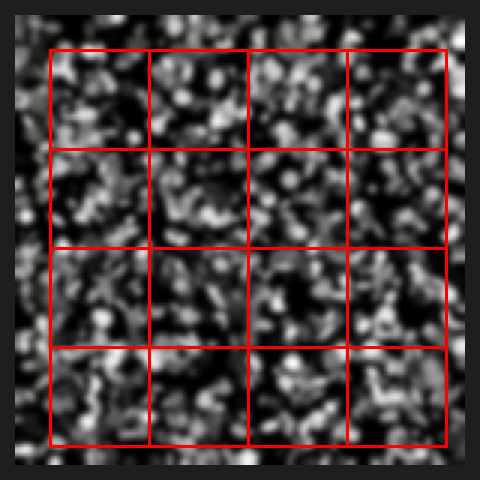

In [12]:
u0 = (150-128)//2
step = 65
step = 33
n = 1 + 128 // (step-1)
u = torch.arange(n) * step + u0
u = [ui.item() for ui in u]
print('u:', u)

ui, vi = [], []
for uii in u:
    ui += [None] + u
    vi += [None] + [uii,] * len(u)

    vi += [None] + u
    ui += [None] + [uii,] * len(u)

image = dataset.dataset0[0]
print('image :', image.shape)
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow((image*255).int(), cmap='gray')
ax.plot(ui, vi, color=(1, 0, 0))
ax.axis('off'), ax.grid(visible=False)
fig.tight_layout(pad=0)
fig.savefig(path_print + 'speckle.pdf')

In [13]:
dataset = speckle_dataset.SpeckleDataset(
    N0=1, scale=4, mode='displacement'
)
dataset.init_dataset0()

torch.manual_seed(6)
(img_ref, img_def), y, _ = dataset.__getitem__(0, case=1)


DATALOADER : DISPLACEMENT


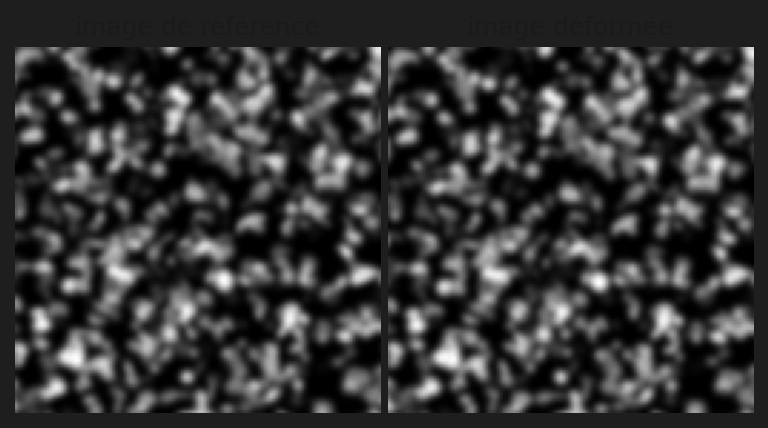

In [14]:
fig, axs = plt.subplots(ncols=2, figsize=(5, 2.7))
axs[0].imshow(img_ref, cmap='gray')
axs[1].imshow(img_def, cmap='gray')
axs[0].axis('off'), axs[0].grid(visible=False)
axs[1].axis('off'), axs[1].grid(visible=False)
axs[0].set_title('image de référence', color='k')
axs[1].set_title('image déformée', color='k')
fig.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95])
graph_tools.savefig(fig, path_print + 'image_pair')

/tmp/ipykernel_6174/3320155525.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.2, rect=[0, -0.1, 1, 1.23])


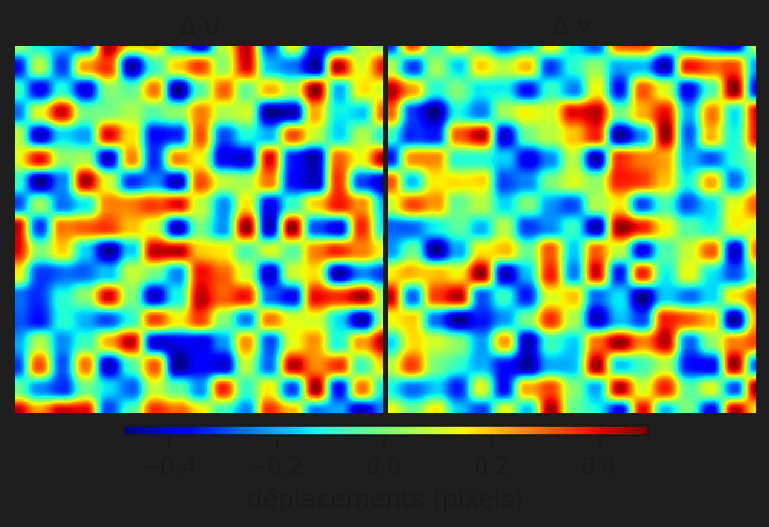

In [15]:
fig, axs = plt.subplots(ncols=2, figsize=(5, 3.35))
im = axs[0].imshow(y[0], cmap='jet')

for i in range(2):
    im = axs[i].imshow(y[i], cmap='jet')
    axs[i].axis('off')
    axs[i].grid(visible=False)
    axs[i].set_title(r'$\Delta$ ' + 'uv'[i], color='k')

cax = fig.add_axes([0.15, 0.155, 0.7, 0.02])  # [left, bottom, width, height]

# Add the colorbar using the 'im' object and the 'cax' axis
cb = fig.colorbar(im, cax=cax, orientation='horizontal')
cb.set_label('déplacements (pixels)', color='k')

fig.tight_layout(pad=0.2, rect=[0, -0.1, 1, 1.23])
graph_tools.savefig(fig, path_print + 'image_pair_deplacements')

In [26]:

u0, v0 = 60.5, 62.5
size = 16
correlator = dic.Correlator(img_ref.to(dic.DEVICE), size, u0, v0)
uv = correlator.get_uv().to('cpu')


correlator.reset_p()
uvs = []
uvcs = []
uvs.append(correlator.get_uv().to('cpu'))
uvcs.append(correlator.get_uvc().to('cpu'))
for i in range(10):
    correlator.update_p(correlator.estim_dp(img_def.to(dic.DEVICE)))
    uvs.append(correlator.get_uv().to('cpu'))
    uvcs.append(correlator.get_uvc().to('cpu'))

correlator.reset_p()
correlator.optim_correlation(img_def.to(dic.DEVICE))
uv2 = correlator.get_uv().to('cpu')

uvc = correlator.get_uvc().to('cpu')
size = 0.8*size

In [ ]:
# fig, axs = plt.subplots(nrows=2, figsize=(2.5, 5))
fig, axs = plt.subplots(ncols=2, figsize=(5, 2.7))
ax = axs[0]
ax.set_title('image de référence', color='k')
ax.imshow(img_ref, cmap='gray')
ax.set_xlim([u0-size, u0+size])
ax.set_ylim([v0+size, v0-size])
ax.axis('off')

ax = axs[1]
ax.set_title('image déformée', color='k')
ax.imshow(img_def, cmap='gray')
ax.set_xlim([u0-size, u0+size])
_ = ax.set_ylim([v0+size, v0-size])
_ = ax.axis('off')

fig.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95])

graph_tools.savefig(fig, path_print + 'dic_example0')

ax = axs[0]
ax.plot([], [], 'o', markersize=1.4)
ax.plot(uv[0], uv[1], 'o', color='r', markersize=3)
ax.plot([u0], [v0], 'o')


ax = axs[1]
# ax.plot(uv[0], uv[1], 'o', markersize=1.4)
ax.plot([], [], 'o', markersize=1.4)
# ax.plot(uv[0], uv[1], 'o', markersize=1.4, label='initial')
dots, = ax.plot(uv2[0], uv2[1], 'o', color='r', markersize=3, label='estimé')
dot, = ax.plot(uvc[:1], uvc[1:], 'o')
# ax.legend(framealpha=0.8)
# ax.plot([u0], [v0], 'o')

graph_tools.savefig(fig, path_print + 'dic_example')

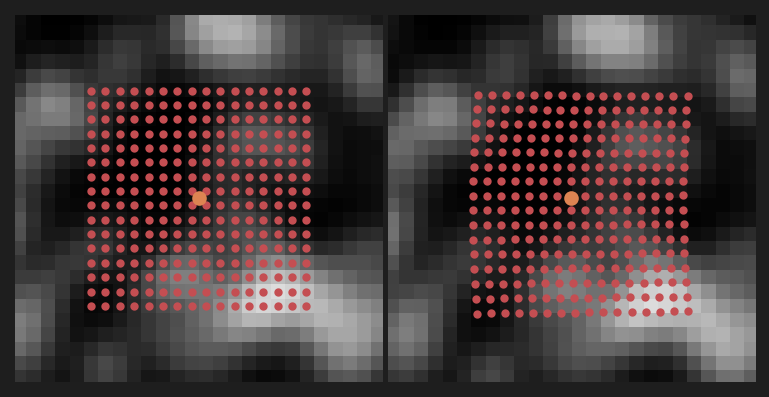

In [27]:
# fig, axs = plt.subplots(nrows=2, figsize=(2.5, 5))
fig, axs = plt.subplots(ncols=2, figsize=(5, 2.7))
ax = axs[0]
# ax.set_title('image de référence', color='k')
ax.imshow(img_ref, cmap='gray')
ax.set_xlim([u0-size, u0+size])
ax.set_ylim([v0+size, v0-size])
ax.axis('off')

ax = axs[1]
# ax.set_title('image déformée', color='k')
ax.imshow(img_def, cmap='gray')
ax.set_xlim([u0-size, u0+size])
_ = ax.set_ylim([v0+size, v0-size])
_ = ax.axis('off')

fig.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95])

graph_tools.savefig(fig, 'diaporama/Figures/dic/' + 'dic_example-0')

correlator.reset_p()
uv = correlator.get_uv().to('cpu')
ax = axs[0]
ax.plot([], [], 'o', markersize=1.4)
ax.plot(uv[0], uv[1], 'o', color='r', markersize=3)
ax.plot([u0], [v0], 'o')

graph_tools.savefig(fig, 'diaporama/Figures/dic/' + 'dic_example-1')


ax = axs[1]
# ax.plot(uv[0], uv[1], 'o', markersize=1.4)
ax.plot([], [], 'o', markersize=1.4)
# ax.plot(uv[0], uv[1], 'o', markersize=1.4, label='initial')
dots, = ax.plot(uv2[0], uv2[1], 'o', color='r', markersize=3, label='estimé')
dot, = ax.plot(uvc[:1], uvc[1:], 'o')
# ax.legend(framealpha=0.8)
# ax.plot([u0], [v0], 'o')


for i in range(len(uvs)):
    uv_i = uvs[i]
    dots.set_data(uv_i[0], uv_i[1])
    uvc = uvcs[i]
    dot.set_data(uvc[:1], uvc[1:])
    fig.canvas.draw()
    fig.canvas.flush_events()
    graph_tools.savefig(fig, 'diaporama/Figures/dic/' + f'dic_example-{i+2}')


# courbes entrainement

In [18]:
optimizer_info = {'Adam': {}}

def scheduler_func(epoch, vmin, vmax, cste, N2):
    if epoch < N2:
        return vmin + (vmax-vmin) * cste**epoch
    
    return 0.1*(vmin + (vmax-vmin) * cste**(epoch-N2))

def plot_lr(optimizer_info, scheduler_info, epochs):
    fig, ax = plt.subplots(figsize=(5,3))
    ax.semilogy(Network.get_scheduler_curve(optimizer_info, scheduler_info, epochs))
    ax.set_xlabel('epoque')
    ax.set_ylabel('learning rate')
    ax.yaxis.grid(which='minor')
    fig.tight_layout()

def plot_map_test_0(trainer, dataset):
    trainer.model.eval()

    for case in [0, 1, 2, 3, 4]:
        X, y, resample_infos = dataset.__getitem__(0, case)
        ur, vr = dataset.uvr
        ur, vr = ur.to('cuda'), vr.to('cuda')

        with torch.no_grad():
            pred = trainer.model(
                X[None], ur, vr, resample_infos[None].to('cuda')
            ).detach().clone().to('cpu')[0]
            y = y.detach().clone().to('cpu')

        # print('y:', y.shape)
        # print('pred:', pred.shape)
        # return
        k = 0
        fig, axs = plt.subplots(
            nrows=y.shape[0], ncols=2,
            figsize=(8, 3.35*y.shape[0])
            )
        fig.suptitle(f'Tailles des éléments : {Hermite.ELEMENT_SIZES[case]} pixels')
        axs[0][0].set_title('prediction')
        axs[0][1].set_title('cible')
        
        for i in range(y.shape[0]):
            vmax = max(torch.abs(pred[i]).max(), torch.abs(y[i]).max())
            im = axs[i][0].imshow(pred[i], cmap='jet', vmin=-vmax, vmax=vmax)
            fig.colorbar(im, shrink=1)
            im =axs[i][1].imshow(y[i], cmap='jet', vmin=-vmax, vmax=vmax)
            fig.colorbar(im, shrink=1)
        
        for i in range(y.shape[0]):
            for j in range(2):
                axs[i][j].axis('off')
                axs[i][j].grid('off')
        fig.tight_layout()

def plot_results(results, clr_train_test=None):
    if clr_train_test is None:
        clr_train_test = 'k'
    fig, ax = plt.subplots()
    
    plot_lr = False
    if plot_lr:
        ax2 = ax.twinx()
        ax.set_zorder(ax2.get_zorder() + 1)
        ax.patch.set_visible(False)
    b_test = False

    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']

    artists = []
    for i, name in enumerate(results):
        data = funcs.load_trainer_results(name)
        label = results[name]
        print(
            f'{label} training time:',
            funcs.chrono(data['compute time'])
        )

        lrs = data['lr']
        loss_tr = data['loss']['train']
        loss_ts = data['loss']['test']

        ln, = ax.semilogy(loss_tr, color=colors[i], label=label)
        tmp = [ln]
        if len(loss_ts) > 0:
            ln, = ax.plot(loss_ts, '--', color=colors[i])
            tmp.append(ln)
            b_test = True

        if plot_lr:
            ln, = ax2.semilogy(lrs, ':')
            tmp.append(ln)
        artists.append(tmp)
    lgd = ax.legend(loc='upper right', ncol=2)
    lgd2 = None
    if b_test:
        hndls = []
        ln, = ax.plot([], [], '-', color=clr_train_test, label='train')
        hndls.append(ln)
        if b_test:
            ln, =ax.plot([], [], '--', color=clr_train_test, label='test')
            hndls.append(ln)
        # ln, = ax.plot([], [], 'k:', label='learning\nrate')
        # hndls.append(ln)
        lgd2 = ax.legend(
            hndls,
            [ln.get_label() for ln in hndls],
            loc='lower left',
        )

        ax.add_artist(lgd)

    if plot_lr:
        ax2.plot(lrs, color='0.5')
        ax2.set_ylabel('learning rate')
        ax2.grid(visible=False)

    # ax.grid(visible=False)
    ax.grid(visible=True)
    ax.grid(which='minor')

    ax.set_xlabel('étape')
    # ax.set_ylabel('MSE loss')
    ax.set_ylabel('pertes (MSE)')
    fig.tight_layout()
    return fig, artists, lgd2

In [8]:
import importlib

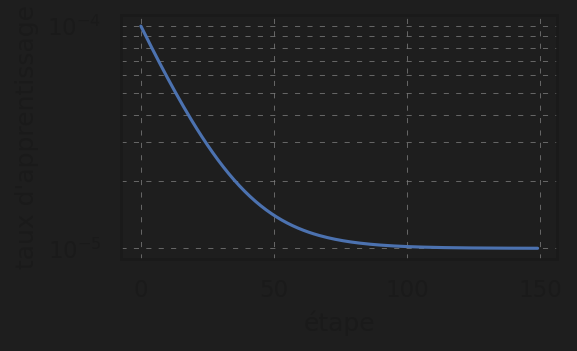

In [4]:
def scheduler_func(epoch, vmin, vmax, cste):
    return vmin + (vmax-vmin) * cste**epoch
    
epochs = torch.arange(150)
lr = scheduler_func(epochs, 1e-5, 1e-4, 0.94)

fig, ax = plt.subplots(figsize=(4,2.5))
ax.set_xlabel('étape')
ax.set_ylabel("taux d'apprentissage")
ax.semilogy(lr)
ax.grid(which='minor')
fig.tight_layout()
graph_tools.savefig(fig, path_print + 'lr')

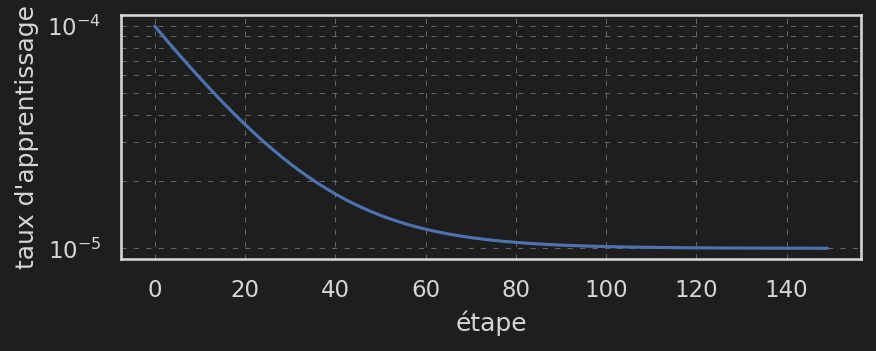

In [6]:
def scheduler_func(epoch, vmin, vmax, cste):
    return vmin + (vmax-vmin) * cste**epoch
    
epochs = torch.arange(150)
lr = scheduler_func(epochs, 1e-5, 1e-4, 0.94)

graph_tools.set_theme(True)
fig, ax = plt.subplots(figsize=(6,2.5))
ax.set_xlabel('étape')
ax.set_ylabel("taux d'apprentissage")
ax.semilogy(lr)
ax.grid(which='minor')
fig.tight_layout()
graph_tools.savefig(fig, 'diaporama/Figures/' + 'lr')

modèle initial
mini batch : 16 training time: 03:45:04.93
group norm (4)
mini batch : 16 training time: 03:32:24.18
group norm (4)
mini batch : 1 training time: 06:09:05.19
group norm (4)
mini batch : 1
Mish training time: 05:24:44.48


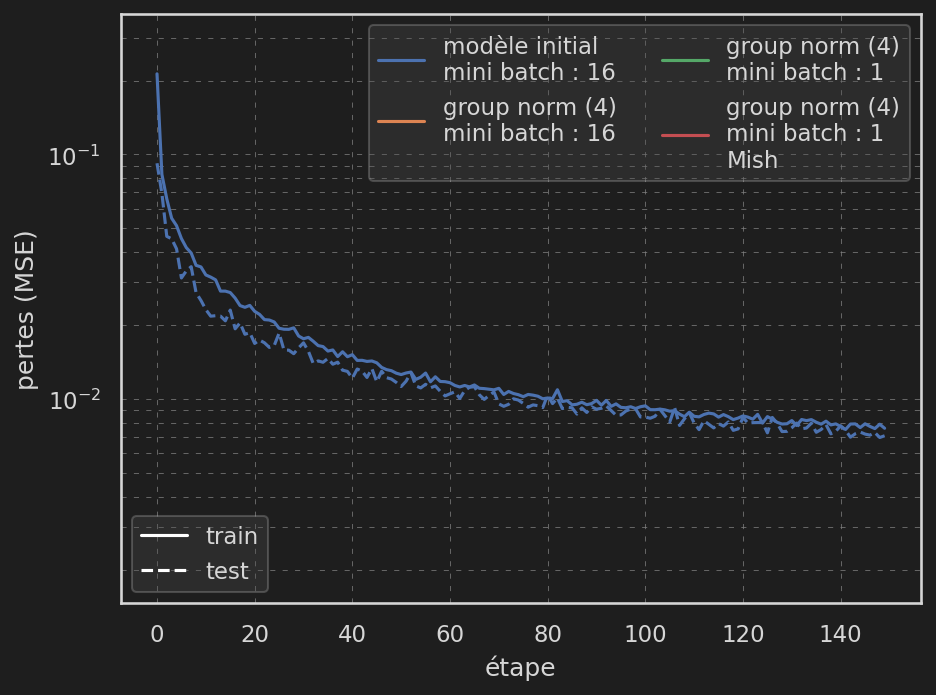

In [16]:
# importlib.reload(graph_tools)
graph_tools.set_theme(True)
results = {
    'initial': 'modèle initial\nmini batch : 16',
    # 'GroupNorm-1': 'group norm (1)',
    'GroupNorm-4': 'group norm (4)\nmini batch : 16',
    'GroupNorm-4-Batch-1': 'group norm (4)\nmini batch : 1',
    'Mish-GN-4-Batch-1': 'group norm (4)\nmini batch : 1\nMish',
}

fig, artists, lgd2 = plot_results(results, 'w')
graph_tools.savefig(fig, 'diaporama/Figures/results-1/' + 'training_4')

for i in range(3):
    for tmp in artists.pop(-1):
        tmp.remove()
    graph_tools.savefig(fig, 'diaporama/Figures/results-1/' + f'training_{3-i}')

Unités résiduelles training time: 05:24:44.48
Dense Conv2d training time: 12:53:56.96
Sep Conv Comb
Dense Conv2d
Sep. Conv2d Aug. (8) training time: 27:52:55.44


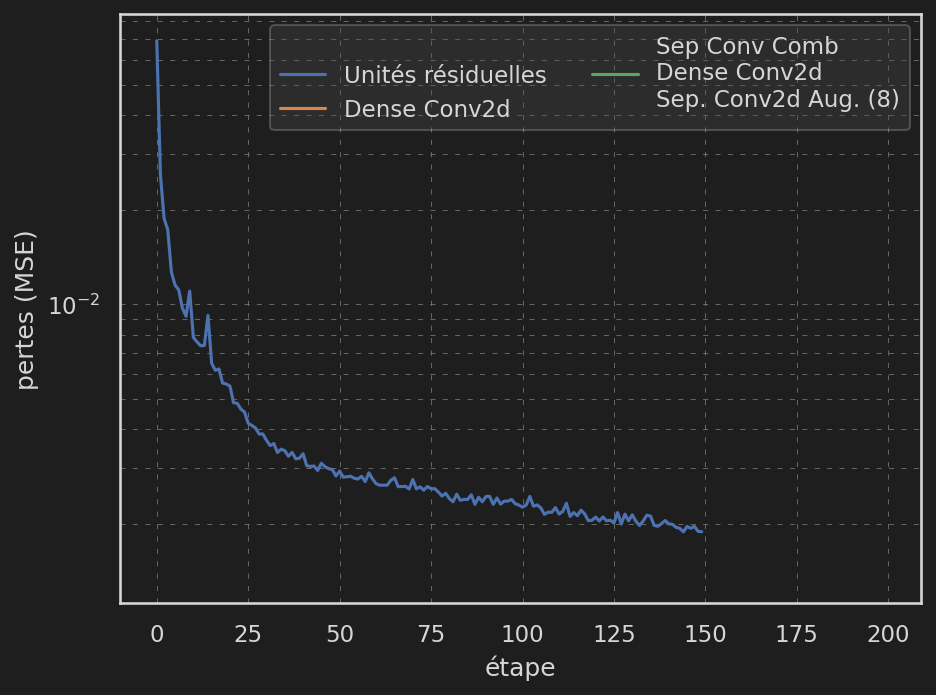

In [23]:
graph_tools.set_theme(True)
results = {
    'Mish-GN-4-Batch-1': 'Unités résiduelles',
    'denseblock/displacement': 'Dense Conv2d',
    # 'denseblock-IncSepConv2d-4/displacement-30': 'Dense Conv2d\nSep. Conv2d Aug. (4)',
    # 'denseblock-IncSepConv2d-8/displacement-20': 'Dense Conv2d\nSep. Conv2d Aug. (8)',
    'SepConvComb-denseblock-IncSepConv2d-8/displacement-200': 'Sep Conv Comb\nDense Conv2d\nSep. Conv2d Aug. (8)',
}


fig, artists, lgd2 = plot_results(results, 'w')
graph_tools.savefig(fig, 'diaporama/Figures/results-2/' + 'training_5')

for i in range(len(artists)-1):
    for tmp in artists.pop(-1):
        tmp.remove()
    graph_tools.savefig(fig, 'diaporama/Figures/results-2/' + f'training_{4-i}')

modèle initial
mini batch : 16 training time: 03:45:04.93
group norm (4)
mini batch : 16 training time: 03:32:24.18
group norm (4)
mini batch : 1 training time: 06:09:05.19
group norm (4)
mini batch : 1
Mish training time: 05:24:44.48


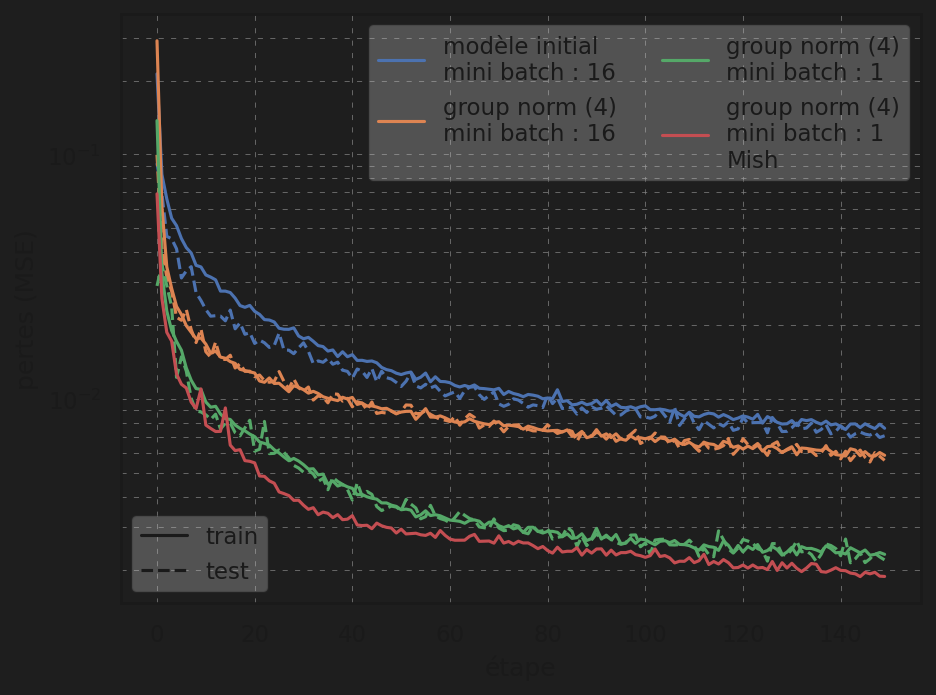

In [9]:
importlib.reload(graph_tools)
graph_tools.set_theme(False)
name = 'sepConv2d-8-Batch1-n_chan_0_96/final-disp'
results = {
    'initial': 'modèle initial\nmini batch : 16',
    # 'GroupNorm-1': 'group norm (1)',
    'GroupNorm-4': 'group norm (4)\nmini batch : 16',
    'GroupNorm-4-Batch-1': 'group norm (4)\nmini batch : 1',
    'Mish-GN-4-Batch-1': 'group norm (4)\nmini batch : 1\nMish',
}

fig = plot_results(results)
graph_tools.savefig(fig, path_print + 'training_1')

Unités résiduelles training time: 05:24:44.48
Dense Conv2d training time: 12:53:56.96
Dense Conv2d
Sep. Conv2d Aug. (4) training time: 02:35:52.56
Dense Conv2d
Sep. Conv2d Aug. (8) training time: 02:45:43.23
Sep Conv Comb
Dense Conv2d
Sep. Conv2d Aug. (8) training time: 27:52:55.44


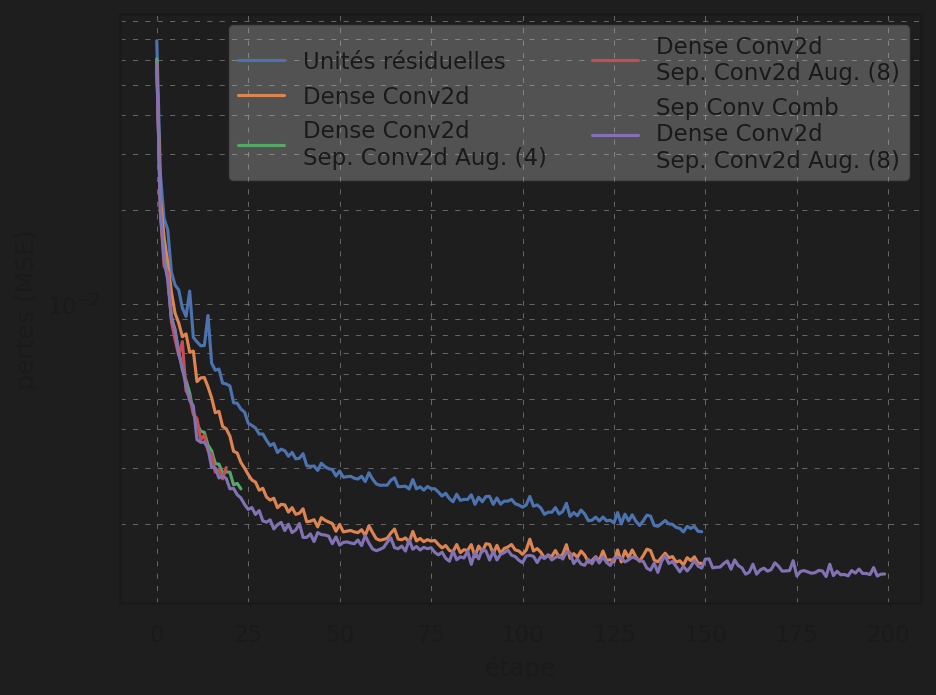

In [25]:
graph_tools.set_theme(False)
name = 'sepConv2d-8-Batch1-n_chan_0_96/final-disp'
results = {
    # 'conv2d/final-disp': 'Conv2d',
    # 'sepConv2d/final-disp-100': 'SepConv2d',
    # 'conv2d/final-disp-00': 'final disp 0',
    # 'sepConv2d-4-Batch1/final-disp-20': 'SepConv2d (4)\nBatch 1',
    # 'sepConv2d-8-Batch1-cst_lr/final-disp-5': 'SepConv2d (8)\nBatch 1\ncst lr',
    # 'SharedSepConv2d-8-Batch1/final-disp': 'SharedSepConv2d (8)',
    # 'SharedSepConv2d-8-Batch1-groups/final-disp': 'SharedSepConv2d (8)\ngroups',
    # 'SharedSepConv2d-0-Batch1/final-disp': 'SepConv2d (0)',
    # 'sepConv2d-8-Batch1-n_chan_0_96/final-disp-30': 'SepConv2d (8)\n96',
    # 'sepConv2d-8-Batch1/final-disp-2': 'SepConv2d (8)\nBatch 1 (2)',
    # 'sepConv2d-8-Batch1/final-disp': 'SepConv2d (8)\nBatch 1',
    # 'Mish-GN-4-SepConv1': 'ResNet',
    # 'DenseConv': 'DenseNet',
    # 'sepConv2d-4/final-disp-50': 'SepConv2d (4)',
    'Mish-GN-4-Batch-1': 'Unités résiduelles',
    'denseblock/displacement': 'Dense Conv2d',
    'denseblock-IncSepConv2d-4/displacement-30': 'Dense Conv2d\nSep. Conv2d Aug. (4)',
    # 'DENSE-SepConv2dComb-Mish-GN-4-Batch-1/displacement': 'Dense Conv2d\nSep. Conv2d Aug. (8)',
    'denseblock-IncSepConv2d-8/displacement-20': 'Dense Conv2d\nSep. Conv2d Aug. (8)',
    'SepConvComb-denseblock-IncSepConv2d-8/displacement-200': 'Sep Conv Comb\nDense Conv2d\nSep. Conv2d Aug. (8)',
}

fig, *_ = plot_results(results)
graph_tools.savefig(fig, path_print + 'training_2')

Sep Cnv Comb
Dense Conv2d
Sep. Conv2d Aug. (8) training time: 29:05:24.04
Sep Cnv Comb
Dense Conv2d
Sep. Conv2d Aug. (8) training time: 27:41:20.52


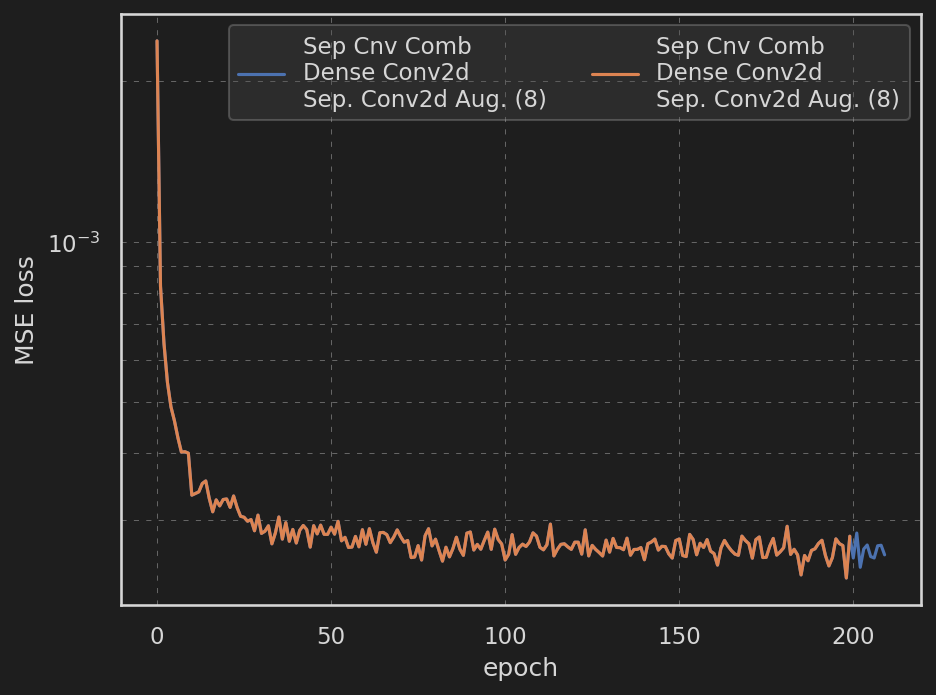

In [127]:
graph_tools.set_theme(True)
results = {
    'SepConvComb-denseblock-IncSepConv2d-8/strain-210': 'Sep Cnv Comb\nDense Conv2d\nSep. Conv2d Aug. (8)',
    'SepConvComb-denseblock-IncSepConv2d-8/strain-200': 'Sep Cnv Comb\nDense Conv2d\nSep. Conv2d Aug. (8)',
    # 'SepConvComb-denseblock-IncSepConv2d-8/strain-10': 'Sep Cnv Comb\nDense Conv2d\nSep. Conv2d Aug. (8)',
}

fig = plot_results(results)
# graph_tools.savefig(fig, path_print + 'training_2')

# Stats

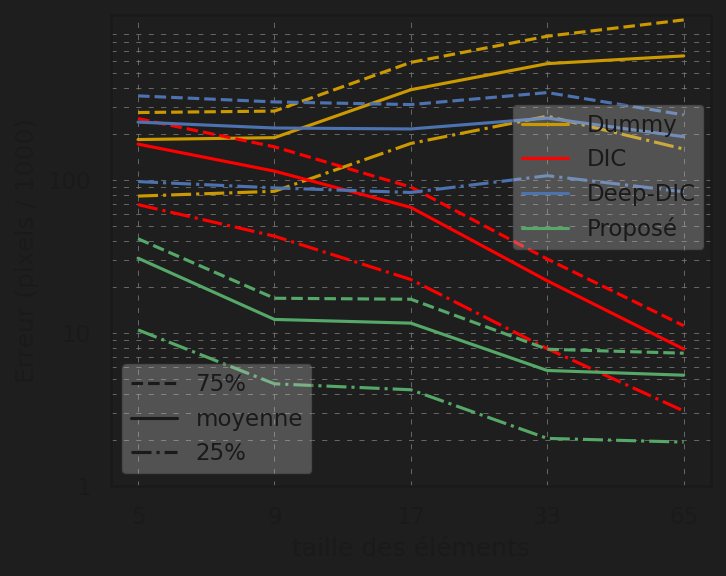

In [12]:
graph_tools.set_theme(False)

dic = {'disp':{}, 'strain':{}}
dic['disp']['avg'] = torch.tensor([0.171726, 0.114339, 0.066242, 0.021934, 0.007845])
dic['disp']['25%'] = torch.tensor([0.069055, 0.042942, 0.022359, 0.007894, 0.003088])
dic['disp']['75%'] = torch.tensor([0.252212, 0.164915, 0.089963, 0.030428, 0.011149])

deepdic = {'disp':{}, 'strain':{}}
deepdic['disp']['avg'] = torch.tensor([0.239258, 0.218837, 0.215781, 0.254139, 0.192059])
deepdic['disp']['25%'] = torch.tensor([0.097679, 0.088836, 0.082896, 0.106767, 0.083764])
deepdic['disp']['75%'] = torch.tensor([0.355026, 0.324183, 0.311331, 0.373111, 0.266849])

proposed = {'disp':{}, 'strain':{}}
proposed['disp']['avg'] = torch.tensor([0.030828, 0.012258, 0.011591, 0.005683, 0.005293])
proposed['disp']['25%'] = torch.tensor([0.01047, 0.00465, 0.004251, 0.002044, 0.001934])
proposed['disp']['75%'] = torch.tensor([0.04129, 0.01686, 0.016613, 0.007824, 0.007371])

dummy = {'disp':{}, 'strain':{}}
dummy['disp']['avg'] = torch.tensor([0.183992, 0.189235, 0.389536, 0.576842, 0.648282])
dummy['disp']['25%'] = torch.tensor([0.078517, 0.084398, 0.173511, 0.261439, 0.159488])
dummy['disp']['75%'] = torch.tensor([0.27625, 0.282373, 0.587807, 0.871714, 1.11464])

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [(0.8, 0.6, 0), (1, 0, 0), 'b', 'g']
elem_size = [5, 9, 17, 33, 65]

fig, ax = plt.subplots(figsize=(5, 4))
for i, (results, label) in enumerate([(dummy, 'Dummy'), (dic, 'DIC'), (deepdic, 'Deep-DIC'), (proposed, 'Proposé')]):
    ax.semilogy(results['disp']['25%']*1e3, '-.', color=colors[i])
    ax.semilogy(results['disp']['75%']*1e3, '--', color=colors[i])
    ax.semilogy(results['disp']['avg']*1e3, color=colors[i], label=label)


ax.set_ylim([1, 1200])
ax.grid(which='minor')
lgd = ax.legend(loc=(0.67, 0.5))

ax.set_yticks([1, 10, 100])
ax.set_yticklabels(['1', '10', '100'])

handles = []
ln, = ax.plot([], [], 'k--', label='75%')
handles.append(ln)
ln, = ax.plot([], [], 'k-', label='moyenne')
handles.append(ln)
ln, = ax.plot([], [], 'k-.', label='25%')
handles.append(ln)

ax.legend(handles, ['75%', 'moyenne', '25%'], loc='lower left')

ax.add_artist(lgd)

ax.set_xticks([i for i in range(len(elem_size))])
ax.set_xticklabels(elem_size)
ax.set_xlabel('taille des éléments')
ax.set_ylabel('Erreur (pixels / 1000)')
fig.tight_layout()
graph_tools.savefig(fig, path_print + 'results_disp')

Remove lgd
Remove lgd
Remove lgd


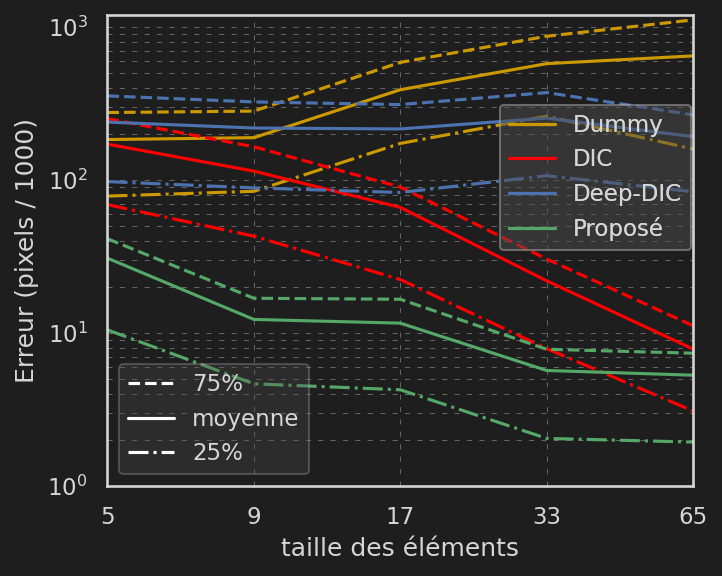

In [41]:
graph_tools.set_theme(True)

dic = {'disp':{}, 'strain':{}}
dic['disp']['avg'] = torch.tensor([0.171726, 0.114339, 0.066242, 0.021934, 0.007845])
dic['disp']['25%'] = torch.tensor([0.069055, 0.042942, 0.022359, 0.007894, 0.003088])
dic['disp']['75%'] = torch.tensor([0.252212, 0.164915, 0.089963, 0.030428, 0.011149])

deepdic = {'disp':{}, 'strain':{}}
deepdic['disp']['avg'] = torch.tensor([0.239258, 0.218837, 0.215781, 0.254139, 0.192059])
deepdic['disp']['25%'] = torch.tensor([0.097679, 0.088836, 0.082896, 0.106767, 0.083764])
deepdic['disp']['75%'] = torch.tensor([0.355026, 0.324183, 0.311331, 0.373111, 0.266849])

proposed = {'disp':{}, 'strain':{}}
proposed['disp']['avg'] = torch.tensor([0.030828, 0.012258, 0.011591, 0.005683, 0.005293])
proposed['disp']['25%'] = torch.tensor([0.01047, 0.00465, 0.004251, 0.002044, 0.001934])
proposed['disp']['75%'] = torch.tensor([0.04129, 0.01686, 0.016613, 0.007824, 0.007371])

dummy = {'disp':{}, 'strain':{}}
dummy['disp']['avg'] = torch.tensor([0.183992, 0.189235, 0.389536, 0.576842, 0.648282])
dummy['disp']['25%'] = torch.tensor([0.078517, 0.084398, 0.173511, 0.261439, 0.159488])
dummy['disp']['75%'] = torch.tensor([0.27625, 0.282373, 0.587807, 0.871714, 1.11464])

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [(0.8, 0.6, 0), (1, 0, 0), 'b', 'g']
elem_size = [5, 9, 17, 33, 65]

fig, ax = plt.subplots(figsize=(5, 4))

ax.set_xticks([i for i in range(len(elem_size))])
ax.set_xticklabels(elem_size)
ax.set_xlabel('taille des éléments')
ax.set_ylabel('Erreur (pixels / 1000)')

handles = []
ln, = ax.plot([], [], 'w--')
handles.append(ln)
ln, = ax.plot([], [], 'w-')
handles.append(ln)
ln, = ax.plot([], [], 'w-.')
handles.append(ln)

lgd0 = ax.legend(handles, ['75%', 'moyenne', '25%'], loc='lower left')
ax.set_ylim([1, 1200])
ax.grid(which='minor')
ax.set_yticks([1, 10, 100])
ax.set_yticklabels(['1', '10', '100'])
ax.autoscale(False)
fig.tight_layout()

handles = []
lgd = None


for i, (results, label) in enumerate([(dummy, 'Dummy'), (dic, 'DIC'), (deepdic, 'Deep-DIC'), (proposed, 'Proposé')]):
    ax.semilogy(results['disp']['25%']*1e3, '-.', color=colors[i])
    ax.semilogy(results['disp']['75%']*1e3, '--', color=colors[i])
    ln, = ax.semilogy(results['disp']['avg']*1e3, color=colors[i], label=label)
    if lgd is not None:
        print('Remove lgd')
        lgd.remove()
    lgd = ax.legend(loc=(0.67, 0.5))
    ax.add_artist(lgd)
    if i == 0:
        ax.add_artist(lgd0)
    graph_tools.savefig(fig, 'diaporama/Figures/' + f'results_disp_{i}')

# tracking

In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

import utilities_tools_and_graph as graph_tools

graph_tools.set_theme(False)
graph_tools.set_theme(False)

In [2]:
# images_path = '/run/media/thomas/ThorAck/Mesures/poutre_unif_LIA/photron/poutre_unif_benchmark_petit_marteau_rouge_/'
# filenames = os.listdir(images_path)
# filenames.sort()
# print(filenames[0])
images_path = 'data/'
filename = 'poutre_unif_benchmark_petit_marteau_rouge_000001.tif'

Isub: (14, 14)


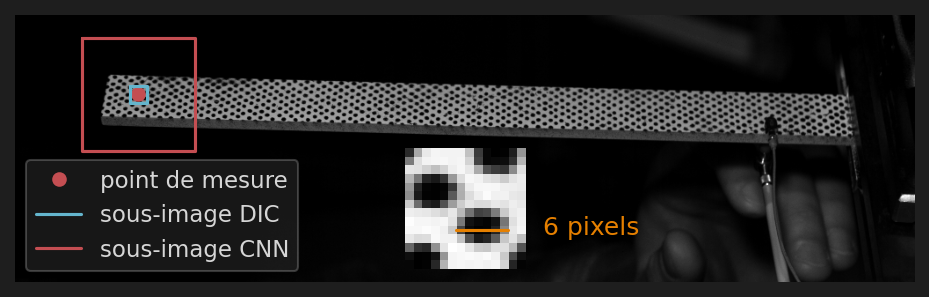

In [8]:
graph_tools.set_theme(True)

img_ref = plt.imread(images_path + filename)

uc, vc = 140, 90
w = 128
u0, u1, v0, v1 = uc-w//2, uc+w//2, vc-w//2, vc+w//2

w2 = 21
u02, u12, v02, v12 = uc-w2//2, uc+w2//2, vc-w2//2, vc+w2//2


fig, ax = plt.subplots(figsize=(6, 6/img_ref.shape[1]*img_ref.shape[0]))
ax.imshow(img_ref, cmap='gray')
ax.grid(visible=False), ax.axis('off')

fig.tight_layout(pad=0)
graph_tools.savefig(fig, 'diaporama/Figures/poutre/' + 'image_poutre0')

ax2 = ax.inset_axes([0.4, 0.05, 0.2, 0.45])
n = 7
Isub = img_ref[vc-n: vc+n, uc-n: uc+n]
print('Isub:', Isub.shape)
ax2.imshow(Isub, cmap='gray')
ax2.grid(visible=False)
ax2.axis('off')
color = (0.9, 0.5, 0)
uc2, vc2 = 8.5, 9
ax2.plot([uc2-3, uc2+3], [vc2, vc2], color=color)
ax.annotate('6 pixels', [600, 250], color=color)

graph_tools.savefig(fig, 'diaporama/Figures/poutre/' + 'image_poutre1')

ax.plot([uc], [vc], 'ro', label='point de mesure')
_ = ax.legend(loc='lower left')

graph_tools.savefig(fig, 'diaporama/Figures/poutre/' + 'image_poutre2')

ax.plot(
    [u02, u12, u12, u02, u02], [v02, v02, v12, v12, v02], 
    'c', label='sous-image DIC')
_ = ax.legend(loc='lower left')
graph_tools.savefig(fig, 'diaporama/Figures/poutre/' + 'image_poutre3')


ax.plot([u0, u1, u1, u0, u0], [v0, v0, v1, v1, v0], 'r', label='sous-image CNN')
_ = ax.legend(loc='lower left')
graph_tools.savefig(fig, 'diaporama/Figures/poutre/' + 'image_poutre4')

graph_tools.savefig(fig, path_print + 'image_poutre')

In [9]:
# sig, sig_2, sig_dic = torch.load('data/results/tracking_32.ph')
sig, sig_2, sig_dic = torch.load('data/results/tracking_128.ph')
path_print = 'rapport/Figures/'

In [10]:
nfft = len(sig[0])
x = np.arange(len(sig[0]))
window = np.exp(x**2 * (np.log(0.001) / x[-1]**2))
window /= window.sum()

def to_FFT(x, window, nfft):
    return np.fft.rfft((x-x.mean()*window), nfft)

SIG = to_FFT(sig[1], window, nfft)
# SIG_2 = to_FFT(sig_2[1], window, nfft)
SIG_DIC = to_FFT(sig_dic[1], window, nfft)
freqs = np.fft.rfftfreq(nfft)

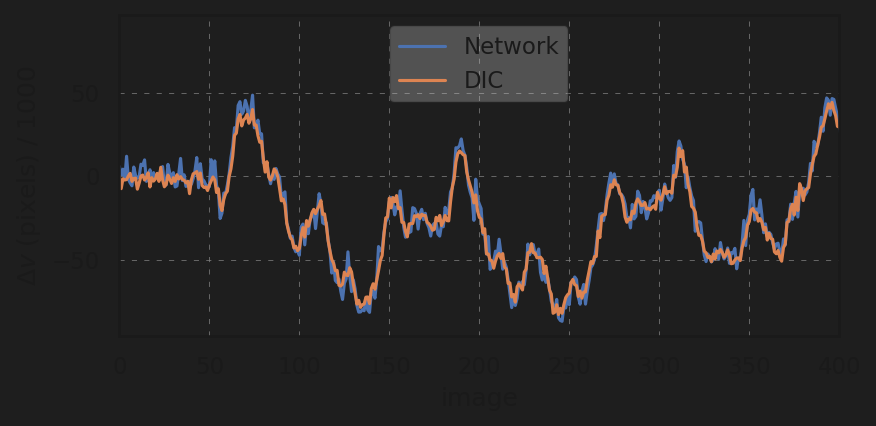

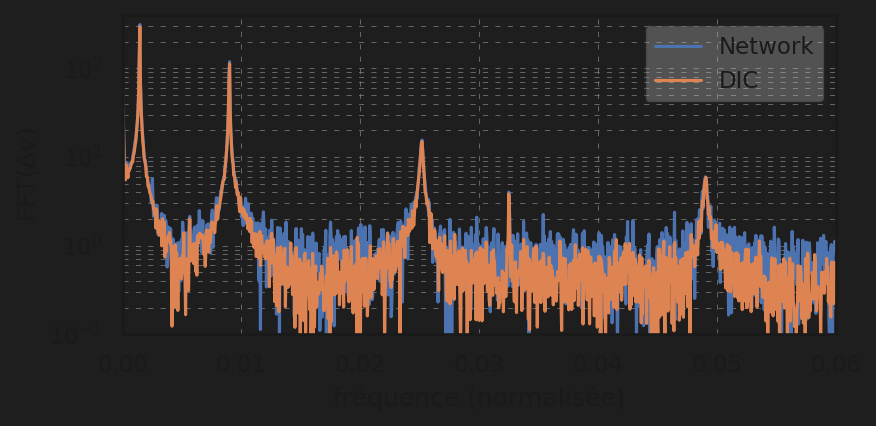

In [15]:
if True:
    graph_tools.set_theme(False)
    tmp_print = path_print
else:
    graph_tools.set_theme(True)
    tmp_print = 'diaporama/Figures/poutre/'


figsize = (6, 3)
fig, ax = plt.subplots(figsize=figsize)
# ax.plot(sig[0], label=r'$\Delta u$')
ax.plot(sig[1]*1000, label=r'Network')

# ax.plot(sig_dic[0]-uc2, label=r'$\Delta u$ DIC')
ax.plot(sig_dic[1]*1000, label=r'DIC')
ax.set_ylabel(r'$\Delta v$ (pixels) / 1000')
ax.legend()
ax.set_xlabel('image')
ax.set_xlim([0, 400])
fig.tight_layout()
graph_tools.savefig(fig, tmp_print + 'tracking_dv')

fig, ax = plt.subplots(figsize=figsize)
ax.semilogy(freqs, np.abs(SIG), label='Network')
# ax.semilogy(freqs, np.abs(SIG_2), label='Network blur')
ax.semilogy(freqs, np.abs(SIG_DIC), label='DIC')
ax.set_ylabel(r'FFT($\Delta v$)')
ax.legend()
ax.grid(which='minor')
ax.set_ylim([1e-1, 400])
# ax.set_xlim([0, 0.125])
ax.set_xlim([0, 0.06])
ax.set_xlabel('fréquence (normalisée)')
fig.tight_layout()
graph_tools.savefig(fig, tmp_print + 'tracking_dv_fft')